## Imports

In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## Locate the project

In [2]:
project_root = Path.cwd().resolve()

while project_root != project_root.parent:
    if (project_root / "data").exists():
        break
    project_root = project_root.parent

fires_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_fires_with_grid_2005_2025.parquet"
)

grid_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_grid_10km.parquet"
)

print("Project root:", project_root)
print("Fire file found:", fires_path.exists())
print("Grid file found:", grid_path.exists())

Project root: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence
Fire file found: True
Grid file found: True


## Load the fires and grid

In [3]:
fires = gpd.read_parquet(fires_path)
grid = gpd.read_parquet(grid_path)

print("Fire records:", len(fires))
print("Grid cells:", len(grid))
print("Fire CRS:", fires.crs.to_epsg())
print("Grid CRS:", grid.crs.to_epsg())

Fire records: 7915
Grid cells: 6501
Fire CRS: 3347
Grid CRS: 3347


## Prepare the fire dates

In [4]:
fires["FIRE_DATE"] = (
    pd.to_datetime(
        fires["FIRE_DATE"],
        errors="coerce",
    )
    .dt.normalize()
)

fires["YEAR"] = fires["FIRE_DATE"].dt.year
fires["MONTH"] = fires["FIRE_DATE"].dt.month
fires["DAY_OF_YEAR"] = fires["FIRE_DATE"].dt.dayofyear

print("Missing dates:", fires["FIRE_DATE"].isna().sum())
print("Earliest date:", fires["FIRE_DATE"].min())
print("Latest date:", fires["FIRE_DATE"].max())

print(
    "Unknown grid IDs:",
    (~fires["GRID_ID"].isin(grid["GRID_ID"])).sum(),
)

Missing dates: 0
Earliest date: 2005-04-06 00:00:00
Latest date: 2025-10-23 00:00:00
Unknown grid IDs: 0


## Examine the temporal distribution

In [5]:
fires_by_year = (
    fires.groupby("YEAR")
    .size()
    .rename("FIRE_COUNT")
)

fires_by_month = (
    fires.groupby("MONTH")
    .size()
    .reindex(range(1, 13), fill_value=0)
    .rename("FIRE_COUNT")
)

display(fires_by_year.to_frame())
display(fires_by_month.to_frame())

,FIRE_COUNT
YEAR,
2005,248
2006,678
2007,380
2008,396
2009,184
2010,583
2011,312
2012,496
2013,494


,FIRE_COUNT
MONTH,
1,0
2,0
3,17
4,517
5,1217
6,1562
7,2701
8,1399
9,379


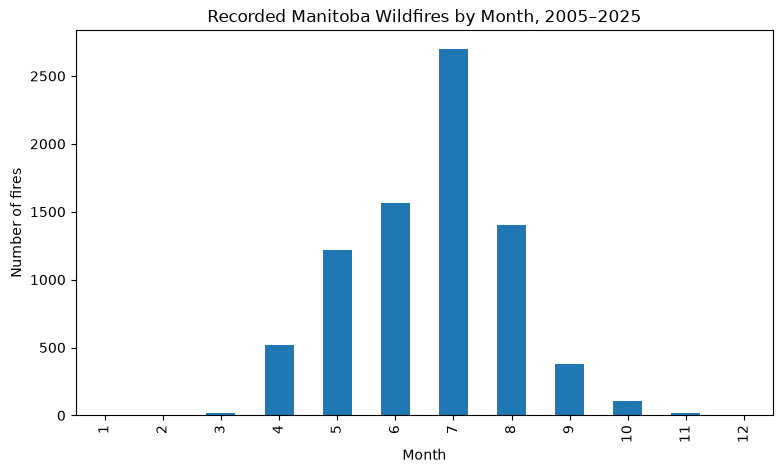

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

fires_by_month.plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Recorded Manitoba Wildfires by Month, 2005–2025")
ax.set_xlabel("Month")
ax.set_ylabel("Number of fires")

plt.show()

## Cause indicators

In [7]:
fires["NATURAL_FIRE"] = (
    fires["CAUSE_LABEL"] == "Natural"
).astype("int8")

fires["HUMAN_FIRE"] = (
    fires["CAUSE_LABEL"] == "Human"
).astype("int8")

fires["UNKNOWN_FIRE"] = (
    fires["CAUSE_LABEL"] == "Unknown"
).astype("int8")

## Positive daily target table

Each row represents a grid cell where at least one new fire was recorded on a particular date.

In [8]:
daily_fire_targets = (
    fires.groupby(
        ["FIRE_DATE", "GRID_ID"],
        as_index=False,
    )
    .agg(
        FIRE_COUNT=("NFDBFIREID", "size"),
        NATURAL_FIRE_COUNT=("NATURAL_FIRE", "sum"),
        HUMAN_FIRE_COUNT=("HUMAN_FIRE", "sum"),
        UNKNOWN_FIRE_COUNT=("UNKNOWN_FIRE", "sum"),
        TOTAL_BURNED_HA=("SIZE_HA", "sum"),
        MAX_FIRE_SIZE_HA=("SIZE_HA", "max"),
    )
)

daily_fire_targets["FIRE_OCCURRED"] = 1

daily_fire_targets = daily_fire_targets.sort_values(
    ["FIRE_DATE", "GRID_ID"]
).reset_index(drop=True)

display(daily_fire_targets.head())

,FIRE_DATE,GRID_ID,FIRE_COUNT,NATURAL_FIRE_COUNT,HUMAN_FIRE_COUNT,UNKNOWN_FIRE_COUNT,TOTAL_BURNED_HA,MAX_FIRE_SIZE_HA,FIRE_OCCURRED
0,2005-04-06,MB_010_042,1,0,1,0,85.0,85.0,1
1,2005-04-08,MB_002_037,1,0,1,0,567.0,567.0,1
2,2005-04-08,MB_031_023,1,0,1,0,15.0,15.0,1
3,2005-04-10,MB_032_024,1,0,1,0,1.5,1.5,1
4,2005-04-15,MB_012_044,1,0,1,0,1.5,1.5,1


In [9]:
print("Original fire records:", len(fires))

print(
    "Fires represented in target table:",
    daily_fire_targets["FIRE_COUNT"].sum(),
)

print(
    "Positive grid-cell days:",
    len(daily_fire_targets),
)

print(
    "Grid-cell days with multiple fires:",
    (daily_fire_targets["FIRE_COUNT"] > 1).sum(),
)

print(
    "Maximum fires in one grid cell on one day:",
    daily_fire_targets["FIRE_COUNT"].max(),
)

print(
    "Duplicate date-grid combinations:",
    daily_fire_targets.duplicated(
        subset=["FIRE_DATE", "GRID_ID"]
    ).sum(),
)

Original fire records: 7915
Fires represented in target table: 7915
Positive grid-cell days: 7356
Grid-cell days with multiple fires: 434
Maximum fires in one grid cell on one day: 10
Duplicate date-grid combinations: 0


## Grid reference table

This will give each grid cell a central coordinate for future weather-data extraction.

In [10]:
grid_centroids = grid[
    [
        "GRID_ID",
        "ROW",
        "COLUMN",
        "MB_AREA_KM2",
        "MB_COVERAGE_PCT",
        "FIRE_COUNT_2005_2025",
        "geometry",
    ]
].copy()

grid_centroids["geometry"] = (
    grid_centroids.geometry.centroid
)

grid_centroids_wgs84 = grid_centroids.to_crs("EPSG:4326")

grid_reference = pd.DataFrame(
    {
        "GRID_ID": grid_centroids_wgs84["GRID_ID"],
        "ROW": grid_centroids_wgs84["ROW"],
        "COLUMN": grid_centroids_wgs84["COLUMN"],
        "CENTER_LATITUDE": (
            grid_centroids_wgs84.geometry.y
        ),
        "CENTER_LONGITUDE": (
            grid_centroids_wgs84.geometry.x
        ),
        "MB_AREA_KM2": (
            grid_centroids_wgs84["MB_AREA_KM2"]
        ),
        "MB_COVERAGE_PCT": (
            grid_centroids_wgs84["MB_COVERAGE_PCT"]
        ),
        "FIRE_COUNT_2005_2025": (
            grid_centroids_wgs84[
                "FIRE_COUNT_2005_2025"
            ]
        ),
    }
)

print("Grid-reference rows:", len(grid_reference))
display(grid_reference.head())

Grid-reference rows: 6501


,GRID_ID,ROW,COLUMN,CENTER_LATITUDE,CENTER_LONGITUDE,MB_AREA_KM2,MB_COVERAGE_PCT,FIRE_COUNT_2005_2025
0,MB_005_000,5,0,49.034036,-101.408339,14.489028,14.489028,0
1,MB_006_000,6,0,49.122970,-101.428824,2.229798,2.229798,0
2,MB_007_000,7,0,49.211928,-101.449396,7.044500,7.044500,0
3,MB_008_000,8,0,49.300912,-101.470056,0.002842,0.002842,0
4,MB_004_001,4,1,48.958440,-101.252939,4.265625,4.265625,0


In [11]:
targets_output_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_daily_fire_targets_2005_2025.parquet"
)

grid_reference_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_grid_reference_10km.parquet"
)

daily_fire_targets.to_parquet(
    targets_output_path,
    index=False,
)

grid_reference.to_parquet(
    grid_reference_path,
    index=False,
)

print("Targets saved:", targets_output_path)
print("Target file exists:", targets_output_path.exists())

print("\nGrid reference saved:", grid_reference_path)
print("Grid reference exists:", grid_reference_path.exists())

Targets saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/data/interim/manitoba_daily_fire_targets_2005_2025.parquet
Target file exists: True

Grid reference saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/data/interim/manitoba_grid_reference_10km.parquet
Grid reference exists: True
